# set up

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
cd /content/drive/MyDrive/codelab/direct_probe/attention

/content/drive/MyDrive/codelab/direct_probe/attention


In [8]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
!pip install adjustText

# load model and weights


In [9]:
import argparse
import torch
import yaml
from models.modeling_bigs_wpos import BiGSForMaskedLM
from models.configuration_bigs import BiGSConfig


def get_codessm(model:str,config_path: str):
  with open(config_path, 'r') as f:
    config_dict = yaml.safe_load(f)
    config_obj = BiGSConfig(
        vocab_size=config_dict['vocab_size'],
        num_hidden_layers=config_dict['num_hidden_layers'],
        hidden_size=config_dict['hidden_size'],
        max_position_embeddings=config_dict['max_position_embeddings'],
    )
    model = BiGSForMaskedLM(config_obj)
    return model


def load_model_weights(model_name: str, config_path: str, weights_path: str = None):
    model = get_codessm(model_name, config_path)
    if weights_path is not None:
        state_dict = torch.load(weights_path, map_location="cpu")
        missing, unexpected = model.load_state_dict(state_dict, strict=False)
        print(f"loading model: {model_name}")
        print(f"Missing keys: {missing}")
        print(f"Unexpected keys: {unexpected}")

    return model


Switch to torch vandermonde kernel.


## loading the pre-trained weights into codessm_sqa model

In [73]:
import yaml
from models.modeling_bigs_wpos import BiGSForTokenClassification
from models.configuration_bigs import BiGSConfig
from collections import OrderedDict

with open('mlm_cosine_bigs_from_sc256.yaml', 'r') as f:
          config = yaml.safe_load(f)

config = BiGSConfig(
    vocab_size=config['vocab_size'],
    num_hidden_layers=config['num_hidden_layers'],
    hidden_size=config['hidden_size'],
    max_position_embeddings=config['max_position_embeddings'],
    num_labels= 1024,
    output_hidden_states=True
)

codessm_sqa = BiGSForTokenClassification(config)
# CPU
state_dict = torch.load("./codessm_sqa.pth", map_location=torch.device('cpu'))

# Fix prefix issue
new_state_dict = OrderedDict()
for k, v in state_dict.items():
    new_key = k
    if new_key.startswith("bigs.bigs."):
        new_key = new_key.replace("bigs.bigs.", "bigs.")
    elif new_key.startswith("predictor."):
        new_key = new_key.replace("predictor.", "classifier.")
    new_state_dict[new_key] = v

# Load weights
missing_keys, unexpected_keys = codessm_sqa.load_state_dict(new_state_dict, strict=False)
print("codessm_sqa Model loaded.")
print("Missing keys:", missing_keys)
print("Unexpected keys:", unexpected_keys)


codessm_sqa Model loaded.
Missing keys: []
Unexpected keys: []


## loading the pre-trained weights into codessm_typeinf model

In [74]:
import yaml
from models.modeling_bigs_wpos import BiGSModel
from models.configuration_bigs import BiGSConfig
from collections import OrderedDict

with open('codessm_typeinf.yaml', 'r') as f:
          config = yaml.safe_load(f)

config = BiGSConfig(
    vocab_size=config['vocab_size'],
    num_hidden_layers=config['num_hidden_layers'],
    hidden_size=config['hidden_size'],
    max_position_embeddings=config['max_position_embeddings'],
    num_labels= 1024,
    output_hidden_states=True
)
codessm_typeinf = BiGSForMaskedLM(config)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
from safetensors.torch import load_file
weights = load_file("./codessm_typeinf.safetensors")
new_state_dict = {
    k.replace("bigs.", ""): v for k, v in weights.items()
}
missing_keys, unexpected_keys= codessm_typeinf.load_state_dict(weights, strict=False)
# Load weights
print("codessm_typeinf Model loaded.")
print("Missing keys:", missing_keys)
print("Unexpected keys:", unexpected_keys)


codessm_typeinf Model loaded.
Missing keys: ['cls.predictions.bias', 'cls.predictions.transform.dense.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.decoder.weight', 'cls.predictions.decoder.bias']
Unexpected keys: ['classifier.bias', 'classifier.weight']


# calculate kernel from weights

In [10]:
import torch
def get_s4_layers(model):
    forward_layers = []
    backward_layers = []
    for i, layer in enumerate(model.bigs.encoder.layer):
        forward_layers.append((f"layer{i}_forward", layer.fs4))
        backward_layers.append((f"layer{i}_backward", layer.bs4))
    return forward_layers,backward_layers


In [11]:
import numpy as np
import torch

def compute_kernel(s4layer, L = 4096):
    with torch.no_grad():
        k = s4layer.kernel(L)
    return k

def compute_kernels_all_layers(forward_layers,backward_layers,L):
  forward_kernels = []
  backward_kernels = []
  print(len(backward_layers))
  for i, (name, forward_layer) in enumerate(forward_layers):
    k_fwd = compute_kernel(forward_layer, L)
    forward_kernels.append({
        "layer_index": i,
        "k_forward": k_fwd,
    })

  for i, (name, backward_layer) in enumerate(backward_layers):
    k_bwd =compute_kernel(backward_layer, L)
    backward_kernels.append({
        "layer_index": i,
        "k_backward": k_bwd,
    })

  return forward_kernels,backward_kernels




In [12]:
codessm_model = load_model_weights("codessm","./modelSSM.yaml","./codessm.pth")

loading model: codessm
Missing keys: []
Unexpected keys: []


In [13]:
codessm_forward_layers,codessm_backward_layers = get_s4_layers(codessm_model)
L = 4096
codessm_forward_kernels,codessm_backward_kernels = compute_kernels_all_layers(codessm_forward_layers,codessm_backward_layers,L)

12


In [76]:
codessm_sqa_forward_layers,codessm_sqa_backward_layers = get_s4_layers(codessm_sqa)
L = 4096
codessm_sqa_forward_kernels,codessm_sqa_backward_kernels = compute_kernels_all_layers(codessm_sqa_forward_layers,codessm_sqa_backward_layers,L)

12


In [77]:
codessm_typeinf_forward_layers,codessm_typeinf_backward_layers = get_s4_layers(codessm_typeinf)
L = 4096
codessm_typeinf_forward_kernels,codessm_typeinf_backward_kernels = compute_kernels_all_layers(codessm_typeinf_forward_layers,codessm_typeinf_backward_layers,L)
print(codessm_typeinf_forward_kernels)

12
[{'layer_index': 0, 'k_forward': tensor([[-0.0855, -0.0232, -0.0012,  ...,  0.0000,  0.0000,  0.0000]])}, {'layer_index': 1, 'k_forward': tensor([[3.5567e-01, 1.8124e-01, 1.2084e-01,  ..., 3.7087e-04, 3.3948e-04,
         3.0518e-04]])}, {'layer_index': 2, 'k_forward': tensor([[-0.3862, -0.2524, -0.1671,  ..., -0.0012, -0.0012, -0.0012]])}, {'layer_index': 3, 'k_forward': tensor([[-5.9774e-02, -2.6860e-02, -1.1748e-02,  ..., -2.6625e-44,
         -2.5223e-44, -2.5223e-44]])}, {'layer_index': 4, 'k_forward': tensor([[-0.5597, -0.4765, -0.0041,  ...,  0.0000,  0.0000,  0.0000]])}, {'layer_index': 5, 'k_forward': tensor([[0.9323, 0.5384, 0.3133,  ..., 0.0000, 0.0000, 0.0000]])}, {'layer_index': 6, 'k_forward': tensor([[-0.8117, -0.6764, -0.3903,  ...,  0.0000,  0.0000,  0.0000]])}, {'layer_index': 7, 'k_forward': tensor([[-0.0753, -0.1203, -0.0259,  ...,  0.0181,  0.0178,  0.0175]])}, {'layer_index': 8, 'k_forward': tensor([[-0.4094, -0.3143, -0.2338,  ...,  0.0000,  0.0000,  0.0000]])

# compute FFT of kernels & returns frequency spectrum

In [14]:
import numpy as np

def kernel_fft(kernel):
    """
    kernels: shape (H,L)
    """
    H, L = kernel.shape
    mag = np.zeros((H, L//2+1))
    freqs = np.fft.rfftfreq(L)
    for h in range(H):
        mag[h] = np.abs(np.fft.rfft(kernel[h]))
    return freqs, mag

In [15]:
import numpy as np

def compute_fft_kernel(forward_kernels, backward_kernels):

    fft_forward = []
    fft_backward = []

    # Forward kernels
    for f in forward_kernels:
        k = f['k_forward']
        freqs, mag = kernel_fft(k)
        fft_forward.append({
            'layer_index': f['layer_index'],
            'freqs': freqs,
            'mag': mag
        })

    # Backward kernels
    for b in backward_kernels:
        k = b['k_backward']
        freqs, mag = kernel_fft(k)
        fft_backward.append({
            'layer_index': b['layer_index'],
            'freqs': freqs,
            'mag': mag
        })

    return fft_forward, fft_backward


In [16]:
codessm_fft_forward, codessm_fft_backward = compute_fft_kernel(codessm_forward_kernels,codessm_backward_kernels)

In [79]:
codessm_sqa_fft_forward, codessm_sqa_fft_backward = compute_fft_kernel(codessm_sqa_forward_kernels,codessm_sqa_backward_kernels)

In [80]:
codessm_typeinf_fft_forward, codessm_typeinf_fft_backward = compute_fft_kernel(codessm_typeinf_forward_kernels,codessm_typeinf_backward_kernels)

In [81]:
print(len(codessm_fft_forward[0]['freqs']))

2049


# metrics


In [18]:
import pandas as pd
def metrics_frequency_domain(fft_forward, fft_backward, model_name):
  rows=[]
  for fft_f, fft_b in zip(fft_forward, fft_backward):

    layer =fft_f['layer_index']
    L =len(fft_f['freqs'])
    low_idx = int(0.1* L)
    high_idx = int(0.6 * L)

    for direction, fft_info in [("forward",fft_f),("backward",fft_b)]:
      H, L = fft_info['mag'].shape
      for h in range(H):

        freqs = fft_info['freqs']
        mag = fft_info['mag'][h]

        #dominant_frequency
        top_idx = np.argmax(mag)
        dominant_f = freqs[top_idx]
        dominant_mag = mag[top_idx]

        #spectral centroid
        centroid = np.sum(freqs * mag) / np.sum(mag)

        #low_to_high_frequency_ratio
        low_energy = np.sum(mag[:low_idx] ** 2)
        high_energy = np.sum(mag[high_idx:] ** 2)
        low_to_high_frequency_ratio= low_energy / high_energy
        log10 = np.log10(low_to_high_frequency_ratio)

        row = {
            "model": model_name,
            "layer": layer+1,
            "direction": direction,
            "dominant_frequency":dominant_f,
            "dominant_magnitude":dominant_mag,
            "spectral_centroid": centroid,
            "low_freq_energy": low_energy,
            "high_freq_energy": high_energy,
            "low_to_high_frequency_ratio":low_to_high_frequency_ratio,
            "log10":log10
            }
        rows.append(row)
  pd.set_option('display.width', 1000)
  return pd.DataFrame(rows)

## codessm metrics

In [83]:
codessm_metrics = metrics_frequency_domain(codessm_fft_forward, codessm_fft_backward ,"CodeSSM")

In [84]:
print(codessm_metrics)

      model  layer direction  dominant_frequency  dominant_magnitude  spectral_centroid  low_freq_energy  high_freq_energy  low_to_high_frequency_ratio     log10
0   CodeSSM      1   forward            0.011475            0.187416           0.189616         6.219419          2.549221                     2.439733  0.387342
1   CodeSSM      1  backward            0.097900            1.075019           0.211536       211.969074        270.784033                     0.782798 -0.106351
2   CodeSSM      2   forward            0.000000            3.617728           0.191760       289.129810         67.026481                     4.313665  0.634846
3   CodeSSM      2  backward            0.009277            2.287508           0.147836       291.198128         20.816453                    13.988845  1.145782
4   CodeSSM      3   forward            0.000732            2.245443           0.175141       368.765041         76.882465                     4.796478  0.680922
5   CodeSSM      3  backward

In [85]:
forward_codessm_metrics= codessm_metrics.iloc[::2]
print(forward_codessm_metrics)

      model  layer direction  dominant_frequency  dominant_magnitude  spectral_centroid  low_freq_energy  high_freq_energy  low_to_high_frequency_ratio     log10
0   CodeSSM      1   forward            0.011475            0.187416           0.189616         6.219419          2.549221                     2.439733  0.387342
2   CodeSSM      2   forward            0.000000            3.617728           0.191760       289.129810         67.026481                     4.313665  0.634846
4   CodeSSM      3   forward            0.000732            2.245443           0.175141       368.765041         76.882465                     4.796478  0.680922
6   CodeSSM      4   forward            0.000000            0.108156           0.128708         0.140970          0.001866                    75.549724  1.878233
8   CodeSSM      5   forward            0.061279            0.986024           0.179692       183.261809         83.164887                     2.203596  0.343132
10  CodeSSM      6   forward

In [86]:
backward_codessm_metrics= codessm_metrics.iloc[1::2]
print(backward_codessm_metrics)

      model  layer direction  dominant_frequency  dominant_magnitude  spectral_centroid  low_freq_energy  high_freq_energy  low_to_high_frequency_ratio     log10
1   CodeSSM      1  backward            0.097900            1.075019           0.211536       211.969074        270.784033                     0.782798 -0.106351
3   CodeSSM      2  backward            0.009277            2.287508           0.147836       291.198128         20.816453                    13.988845  1.145782
5   CodeSSM      3  backward            0.000000            4.357226           0.144896       887.344599         47.598760                    18.642179  1.270497
7   CodeSSM      4  backward            0.000000          202.160461           0.047753     62932.810500          6.126875                 10271.600997  4.011638
9   CodeSSM      5  backward            0.006104            1.207357           0.204899       265.353308        199.775744                     1.328256  0.123282
11  CodeSSM      6  backward

## codessm_sqa metrics

In [98]:
codessm_sqa_metrics = metrics_frequency_domain(codessm_sqa_fft_forward, codessm_sqa_fft_backward,"codessm_sqa")
print(codessm_sqa_metrics)

          model  layer direction  dominant_frequency  dominant_magnitude  spectral_centroid  low_freq_energy  high_freq_energy  low_to_high_frequency_ratio     log10
0   codessm_sqa      1   forward            0.010254            0.134028           0.189808         2.976668          1.212044                     2.455907  0.390212
1   codessm_sqa      1  backward            0.086670            1.142478           0.206194       247.369363        260.085704                     0.951107 -0.021771
2   codessm_sqa      2   forward            0.000000            4.031903           0.194499       311.182658         78.965464                     3.940744  0.595578
3   codessm_sqa      2  backward            0.011963            1.845016           0.151555       271.174325         22.851768                    11.866667  1.074329
4   codessm_sqa      3   forward            0.009277            3.455291           0.176384       316.958809         68.832907                     4.604757  0.663207
5   

In [99]:
forward_codessm_sqa_metrics= codessm_sqa_metrics.iloc[::2]
print(forward_codessm_sqa_metrics)

          model  layer direction  dominant_frequency  dominant_magnitude  spectral_centroid  low_freq_energy  high_freq_energy  low_to_high_frequency_ratio     log10
0   codessm_sqa      1   forward            0.010254            0.134028           0.189808         2.976668          1.212044                     2.455907  0.390212
2   codessm_sqa      2   forward            0.000000            4.031903           0.194499       311.182658         78.965464                     3.940744  0.595578
4   codessm_sqa      3   forward            0.009277            3.455291           0.176384       316.958809         68.832907                     4.604757  0.663207
6   codessm_sqa      4   forward            0.019287            0.141803           0.192575         3.611769          1.650936                     2.187710  0.339990
8   codessm_sqa      5   forward            0.053955            1.029487           0.177719       203.669257         83.919857                     2.426950  0.385061
10  

In [100]:
backward_codessm_sqa_metrics= codessm_sqa_metrics.iloc[1::2]
print(backward_codessm_sqa_metrics)

          model  layer direction  dominant_frequency  dominant_magnitude  spectral_centroid  low_freq_energy  high_freq_energy  low_to_high_frequency_ratio     log10
1   codessm_sqa      1  backward            0.086670            1.142478           0.206194       247.369363        260.085704                     0.951107 -0.021771
3   codessm_sqa      2  backward            0.011963            1.845016           0.151555       271.174325         22.851768                    11.866667  1.074329
5   codessm_sqa      3  backward            0.000000            4.584295           0.143775       618.235604         31.119327                    19.866612  1.298124
7   codessm_sqa      4  backward            0.000244          111.953789           0.051109     27474.578444          4.962595                  5536.332858  3.743222
9   codessm_sqa      5  backward            0.009277            0.953213           0.206675       166.783596        137.871453                     1.209704  0.082679
11  

## codessm_typeinf metrics

In [101]:
codessm_typeinf_metrics = metrics_frequency_domain(codessm_typeinf_fft_forward, codessm_typeinf_fft_backward,"codessm_typeinf")
print(codessm_typeinf_metrics)

              model  layer direction  dominant_frequency  dominant_magnitude  spectral_centroid  low_freq_energy  high_freq_energy  low_to_high_frequency_ratio     log10
0   codessm_typeinf      1   forward            0.000000            0.132691           0.223309         1.932795          3.940226                     0.490529 -0.309335
1   codessm_typeinf      1  backward            0.120850            0.904788           0.201378       108.146201        124.390962                     0.869406 -0.060778
2   codessm_typeinf      2   forward            0.000000            3.366078           0.181952       308.492757         53.682721                     5.746593  0.759410
3   codessm_typeinf      2  backward            0.013672            2.664223           0.144664       364.325548         24.109031                    15.111580  1.179310
4   codessm_typeinf      3   forward            0.001221            3.193425           0.174884       252.851960         51.183084                    

In [102]:
forward_codessm_typeinf_metrics= codessm_typeinf_metrics.iloc[::2]
print(forward_codessm_typeinf_metrics)

              model  layer direction  dominant_frequency  dominant_magnitude  spectral_centroid  low_freq_energy  high_freq_energy  low_to_high_frequency_ratio     log10
0   codessm_typeinf      1   forward            0.000000            0.132691           0.223309         1.932795          3.940226                     0.490529 -0.309335
2   codessm_typeinf      2   forward            0.000000            3.366078           0.181952       308.492757         53.682721                     5.746593  0.759410
4   codessm_typeinf      3   forward            0.001221            3.193425           0.174884       252.851960         51.183084                     4.940147  0.693740
6   codessm_typeinf      4   forward            0.000000            0.208523           0.201755         2.487447          1.569082                     1.585288  0.200108
8   codessm_typeinf      5   forward            0.076172            1.087747           0.184034       170.697407        100.166070                    

In [104]:
backward_codessm_typeinf_metrics= codessm_typeinf_metrics.iloc[1::2]
print(backward_codessm_typeinf_metrics)

              model  layer direction  dominant_frequency  dominant_magnitude  spectral_centroid  low_freq_energy  high_freq_energy  low_to_high_frequency_ratio     log10
1   codessm_typeinf      1  backward            0.120850            0.904788           0.201378       108.146201        124.390962                     0.869406 -0.060778
3   codessm_typeinf      2  backward            0.013672            2.664223           0.144664       364.325548         24.109031                    15.111580  1.179310
5   codessm_typeinf      3  backward            0.000000            3.246581           0.147292       540.783172         30.238392                    17.883992  1.252464
7   codessm_typeinf      4  backward            0.000000          239.177444           0.073898     63680.787271         17.687194                  3600.389415  3.556349
9   codessm_typeinf      5  backward            0.019531            0.396474           0.188873        27.537966         11.557540                    

# frequency response diagram


In [40]:
from adjustText import adjust_text
os.makedirs("./plots/magnitude_of_codessm", exist_ok=True)
def plot_frequency_response(fft_forward, fft_backward,model_name):
  layers=len(fft_forward)
  for layer in range(layers):
        for direction in ['forward', 'backward']:
            if direction == 'forward':
                    kernels_info = fft_forward[layer]
            else:
                    kernels_info = fft_backward[layer]
            H, L = kernels_info['mag'].shape
            for h in range(H):
              freqs = kernels_info['freqs']
              mag = kernels_info['mag'][h]

              #dominant_frequency
              top_idx = np.argmax(mag)
              dominant_f = freqs[top_idx]
              dominant_mag = mag[top_idx]


              #mark dominant_frequency and dominant_magnitude
              plt.figure(figsize=(6, 4), dpi=300)

              plt.plot(freqs, mag, label=model_name, linewidth=0.9, alpha=0.9)
              plt.plot(dominant_f , dominant_mag, marker='o', markersize=12, markeredgecolor='k', markeredgewidth=0.4
                        )

              #spectral centroid
              centroid = np.sum(freqs * mag) / np.sum(mag)
              y_centroid = np.interp(centroid, freqs, mag)
              plt.plot(centroid, y_centroid, '^', markersize=12,markeredgecolor='k', markeredgewidth=0.4)

              plt.xticks(fontsize=20)
              plt.yticks(fontsize=20)
              plt.xlabel("Frequency(cycles per sample)",fontsize=22)
              plt.ylabel("Magnitude",fontsize=22)

              plt.grid(True,linestyle=':', linewidth=0.5)
              plt.tight_layout()
              print(f"{model_name}_Layer_{layer+1}_{direction}.pdf")
              plt.savefig(os.path.join("./plots/magnitude_of_codessm", f"{model_name}_Layer_{layer+1}_{direction}.pdf"), dpi=300)

              plt.show()


In [41]:
model_name="CodeSSM"
plot_frequency_response(codessm_fft_forward, codessm_fft_backward,model_name)

Output hidden; open in https://colab.research.google.com to view.

#plot spectral centroid on x-axis and Log10(LHFR) on y-axis

In [42]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
from adjustText import adjust_text

def classification(data,model_name):

    fig, ax = plt.subplots(figsize=(12,7))

    colors = {'forward':'blue', 'backward':'red'}
    marker_shapes = {'forward':'^', 'backward':'o'}
    marker_size = 120
    marker_radius = np.sqrt(marker_size)/2

    # set margin on a plot
    x_min = data['spectral_centroid'].min()
    x_max = data['spectral_centroid'].max()
    y_min = data['log10'].min()
    y_max = data['log10'].max()
    x_margin = (x_max - x_min) * 0.03
    y_margin = (y_max - y_min) * 0.06
    ax.set_xlim(x_min - x_margin, x_max + x_margin)
    ax.set_ylim(y_min - y_margin, y_max + y_margin)

    # retrieve the current range of the axes
    ax_xmin, ax_xmax = ax.get_xlim()
    ax_ymin, ax_ymax = ax.get_ylim()

    # set threshold
    vboundary = 0.166
    hboundary_lowpass = 1.0
    hboundary_highpass = 0.0


    # --- HIGH-PASS REGION ---
    hp_x0 = max(0.166, ax_xmin)
    hp_x1 = ax_xmax
    hp_y0 = ax_ymin
    hp_y1 = min(hboundary_highpass, ax_ymax)
    hp_w = hp_x1 - hp_x0
    hp_h = hp_y1 - hp_y0
    if hp_w > 0 and hp_h > 0:
      rect_highpass = patches.Rectangle(
            (hp_x0, hp_y0), hp_w, hp_h,
            facecolor='blue', alpha=0.12, zorder=0
        )
      ax.add_patch(rect_highpass)

    #  LOW-PASS REGION (x < 0.166 AND y > 1.0)
    lp_x0 = ax_xmin
    lp_x1 = min(vboundary, ax_xmax)
    lp_y0 = max(hboundary_lowpass, ax_ymin)
    lp_y1 = ax_ymax
    lp_w = lp_x1 - lp_x0
    lp_h = lp_y1 - lp_y0

    if lp_w > 0 and lp_h > 0:
        rect_lowpass = patches.Rectangle(
            (lp_x0, lp_y0), lp_w, lp_h,
            facecolor='yellow', alpha=0.12, zorder=0
        )
        ax.add_patch(rect_lowpass)

    # BAND-PASS REGION x >= 0.166 and 0 <= y <= 1.0
    bp_x0 = max(vboundary, ax_xmin)
    bp_x1 = ax_xmax
    bp_y0 = max(hboundary_highpass, ax_ymin)
    bp_y1 = min(hboundary_lowpass, ax_ymax)
    bp_w = bp_x1 - bp_x0
    bp_h = bp_y1 - bp_y0
    if bp_w > 0 and bp_h > 0:
        rect_bandpass = patches.Rectangle(
            (bp_x0, bp_y0), bp_w, bp_h,
            facecolor='green', alpha=0.08, zorder=0
        )
        ax.add_patch(rect_bandpass)


    texts = []
    # Low-pass label
    if lp_w > 0 and lp_h > 0:
       ax.text(
            lp_x0 + lp_w * 0.5,
            lp_y0 + lp_h * 0.7 ,
            'low-pass', color='goldenrod', fontsize=24, weight='bold',
            ha='center', va='center', zorder=2
        )
    # High-pass label
    if hp_w > 0 and hp_h > 0:
       ax.text(
            hp_x0 + hp_w * 0.3,
            hp_y0 + hp_h * 0.5,
            'high-pass', color='darkblue', fontsize=24, weight='bold',
            ha='center', va='center', zorder=2
        )
    # Band-pass label
    if bp_w > 0 and bp_h > 0:
      ax.text(
            bp_x0 + bp_w * 0.6 ,
            bp_y0 + bp_h * 0.5,
            'band-pass', color='darkgreen', fontsize=24, weight='bold',
            ha='center', va='center', zorder=2
        )


    # Vertical decision line at x = 0.166
    if ax_xmin < vboundary < ax_xmax:
        ax.vlines(vboundary, ax_ymin, ax_ymax, color='green', linestyle='--', linewidth=1.0, zorder=1)
        # annotate
        ax.annotate(
            'x = 0.166',
            xy=(vboundary, ax_ymax - (ax_ymax - ax_ymin) * 0.06), # specifies where the arrow points to
            xytext=(vboundary + (ax_xmax - ax_xmin) * 0.03, ax_ymax - (ax_ymax - ax_ymin) * 0.06), # specifies where the text label appears
            color='green', fontsize=20,
            arrowprops=dict(arrowstyle='->', color='green', lw=0.8),
            zorder=5
        )

    # Horizontal boundaries y = 0 and y = 1.0
    if ax_ymin < 0 < ax_ymax:
        ax.hlines(0, ax_xmin, ax_xmax, color='blue', linestyle='--', linewidth=1.0, zorder=1)
        ax.text(ax_xmin + (ax_xmax - ax_xmin)*0.01, (ax_ymax - ax_ymin)*0.01,
                'y = 0', color='blue', fontsize=20, ha='left', va='bottom', zorder=6)

    if ax_ymin < 1.0 < ax_ymax:
        ax.hlines(1.0, ax_xmin, ax_xmax, color='goldenrod', linestyle='--', linewidth=1.0, zorder=1)
        ax.text(ax_xmin + (ax_xmax - ax_xmin)*0.01, 1.0 + (ax_ymax - ax_ymin)*0.01,
                'y = 1.0', color='goldenrod', fontsize=20, ha='left', va='bottom', zorder=6)

    # plots individual data points as markers on graph
    for direction in data['direction'].unique():
        subset = data[data['direction'] == direction]
        ax.scatter(
            subset['spectral_centroid'], subset['log10'],
            c=colors[direction],
            label=direction,
            s=marker_size,
            alpha=1.0,
            edgecolor='k',
            marker=marker_shapes[direction],
            linewidths=0.6,
            zorder=3
        )
    for _, row in data.iterrows():
        txt_color = 'blue' if row['direction'] == 'forward' else 'black'
        texts.append(
            ax.text(
                row['spectral_centroid'],
                row['log10'] + (marker_radius * 0.01),
                str(row['layer']),
                fontsize=24,
                color=txt_color,
                zorder=4
            )
        )
    adjust_text(
        texts,
        expand_points=(1.5, 1.5),
        expand_text=(3, 3),
        force_text=10.0,
        force_points=5.0,
        arrowprops=dict(arrowstyle='->', color='gray', lw=0.5),
        autoalign=True
    )

    plt.xticks(fontsize=24)
    plt.yticks(fontsize=24)
    ax.set_xlabel('Spectral centroid',fontsize=24)
    ax.set_ylabel(r'$\log_{10}(LHFR)$',fontsize=24)
    ax.legend(fontsize=22,loc='best')

    plt.tight_layout()
    plt.savefig(f"./{model_name}_filter_distribution_based_on_spectral_centroid_and_LTHER.pdf", dpi=300)
    plt.show()


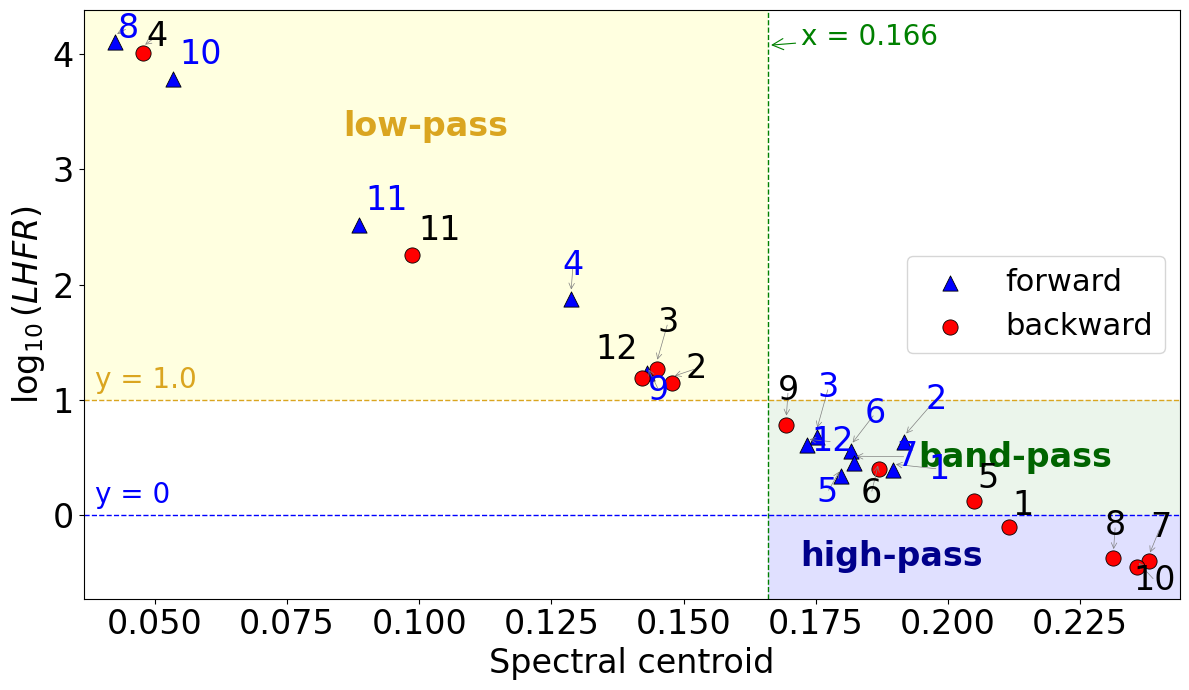

In [43]:
model_name="CodeSSM"
classification(codessm_metrics,model_name)

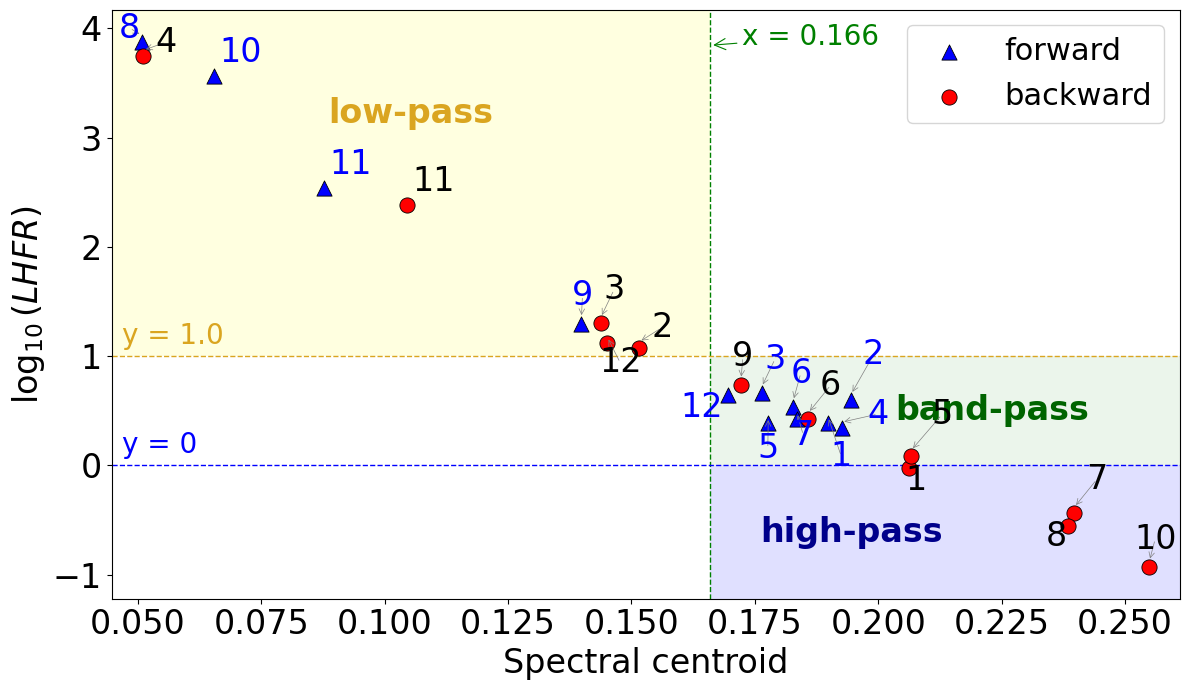

In [105]:
model_name="codessm_sqa"
classification(codessm_sqa_metrics,model_name)

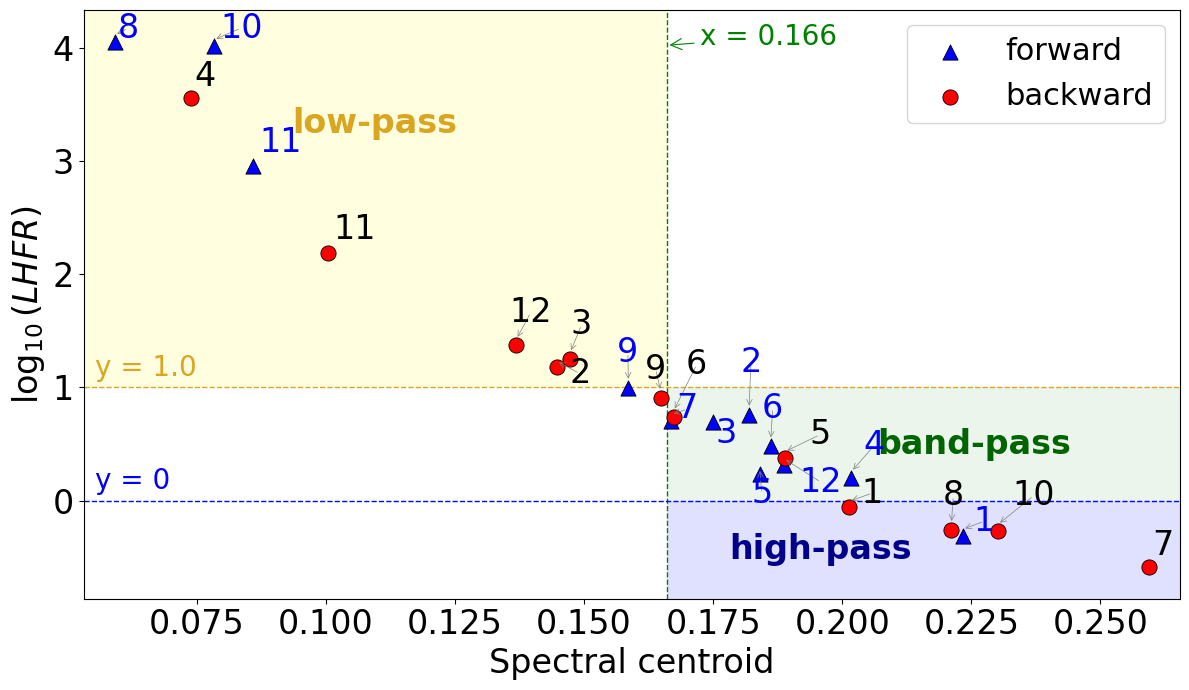

In [106]:
model_name="codessm_typeinf"
classification(codessm_typeinf_metrics,model_name)

#layer-wise filter classification

In [61]:


def assign_region_per_row(row):

    # set threshold
    vboundary = 0.166
    hboundary_lowpass = 1.0
    hboundary_highpass = 0.0

    x=row['spectral_centroid']
    y=row['log10']
    # High-pass region
    if y <= hboundary_highpass:
        return 'high-pass'

    # Low-pass region
    elif x < vboundary and y > hboundary_lowpass :
        return 'low-pass'

    # band-pass
    elif x >= vboundary and hboundary_highpass < y <= hboundary_lowpass :
        return 'band-pass'

    # outliner
    if x < vboundary:
      return 'low-pass' if hboundary_lowpass -y < vboundary -x else 'band-pass'
    if x > vboundary:
      return 'low-pass' if x - vboundary < y - hboundary_lowpass  else 'band-pass'

def classify_all_kernels(data):
  #for _, row in data.iterrows():
    data['region'] = data.apply(lambda row: assign_region_per_row(row), axis=1)
    return data

In [71]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patheffects as pe
from matplotlib.colors import ListedColormap

filters = ["low-pass", "band-pass", "high-pass"]
num_layers = 12

group_spans = { # 0-based indices
    "Early layer": (0,3),   # layer 1-4
    "Middle layer": (4,8),  # layer 5-8
    "Late layer": (9,11)    # layer 9-12
}
def generate_layer_wise_classification_metrix(model_metrics_forward, model_metrics_backward):
    # Build matrices
    forward_matrix = np.zeros((len(filters), num_layers))
    backward_matrix = np.zeros((len(filters), num_layers))

    for idx, (i, row) in enumerate(model_metrics_forward.iterrows()):
        if row['region'] == 'low-pass':
            forward_matrix[0, idx] = 1
        elif row['region'] == 'band-pass':
            forward_matrix[1, idx] = 1
        elif row['region'] == 'high-pass':
            forward_matrix[2, idx] = 1

    for idx, (i, row) in enumerate(model_metrics_backward.iterrows()):
        if row['region'] == 'low-pass':
            backward_matrix[0, idx] = 1
        elif row['region'] == 'band-pass':
            backward_matrix[1, idx] = 1
        elif row['region'] == 'high-pass':
            backward_matrix[2, idx] = 1

    return forward_matrix, backward_matrix

def layer_wise_classification_plot(mat, modelName, direction):
    fig, ax = plt.subplots(figsize=(14, 4))
    # "#2e004d" -> background, "#ffd700" -> highlighted cell
    cmap = ListedColormap(["#2e004d", "#ffd700"])

    im = ax.imshow(mat, cmap=cmap, vmin=0, vmax=1)
    # boundaries
    group_edges = [4, 8]  # Early (1–4), Middle (5–8), Late (9–12)

    # separating lines
    for edge in group_edges:
       ax.axvline(edge - 0.5, color="white", linewidth=2)

    # Add top labels
    for gname, (start_idx, end_idx) in group_spans.items():
        ax.text((start_idx+end_idx)/2, -0.8, gname, ha='center', va='center', fontsize=22)

    # Tick labels
    ax.set_xticks(np.arange(num_layers))
    ax.set_xticklabels(np.arange(1, num_layers + 1))
    ax.set_yticks(np.arange(len(filters)))
    ax.set_yticklabels(filters)
    ax.tick_params(axis='both', which='major', labelsize=22)


    # Add layer numbers inside highlighted cells
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            if mat[i, j] == 1:
                txt = ax.text(j, i, str(j+1), ha="center", va="center", fontsize=22, fontweight='bold', color='black')

    #set xy label
    ax.set_xlabel("Layer Index",fontsize=22)
    ax.set_ylabel("Filter Type",fontsize=22)
    plt.tight_layout()
    plt.show()
    #fig.savefig(f"./{modelName}_kernel_classification_layer_wise_{direction}.pdf", dpi=300)
    return fig, ax


## codessm layer-wise classification graph

In [112]:
forward_codessm_metrics_with_region = classify_all_kernels(forward_codessm_metrics.copy())
print(forward_codessm_metrics_with_region[['layer', 'direction', 'log10','region']])

    layer direction     log10     region
0       1   forward  0.387342  band-pass
2       2   forward  0.634846  band-pass
4       3   forward  0.680922  band-pass
6       4   forward  1.878233   low-pass
8       5   forward  0.343132  band-pass
10      6   forward  0.555259  band-pass
12      7   forward  0.455875  band-pass
14      8   forward  4.107944   low-pass
16      9   forward  1.230637   low-pass
18     10   forward  3.786961   low-pass
20     11   forward  2.519050   low-pass
22     12   forward  0.603980  band-pass


In [111]:
backward_codessm_metrics_with_region = classify_all_kernels(backward_codessm_metrics.copy())
print(backward_codessm_metrics_with_region[['layer', 'direction','spectral_centroid', 'log10','region']])

    layer direction  spectral_centroid     log10     region
1       1  backward           0.211536 -0.106351  high-pass
3       2  backward           0.147836  1.145782   low-pass
5       3  backward           0.144896  1.270497   low-pass
7       4  backward           0.047753  4.011638   low-pass
9       5  backward           0.204899  0.123282  band-pass
11      6  backward           0.186884  0.398274  band-pass
13      7  backward           0.237995 -0.402081  high-pass
15      8  backward           0.231277 -0.373958  high-pass
17      9  backward           0.169400  0.784334  band-pass
19     10  backward           0.235705 -0.452124  high-pass
21     11  backward           0.098677  2.257121   low-pass
23     12  backward           0.142038  1.190665   low-pass


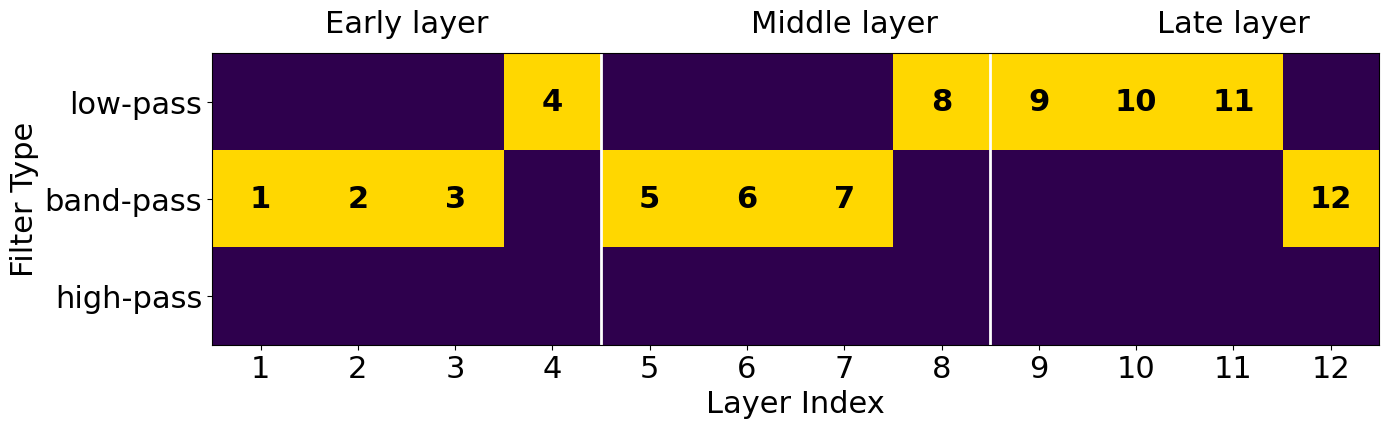

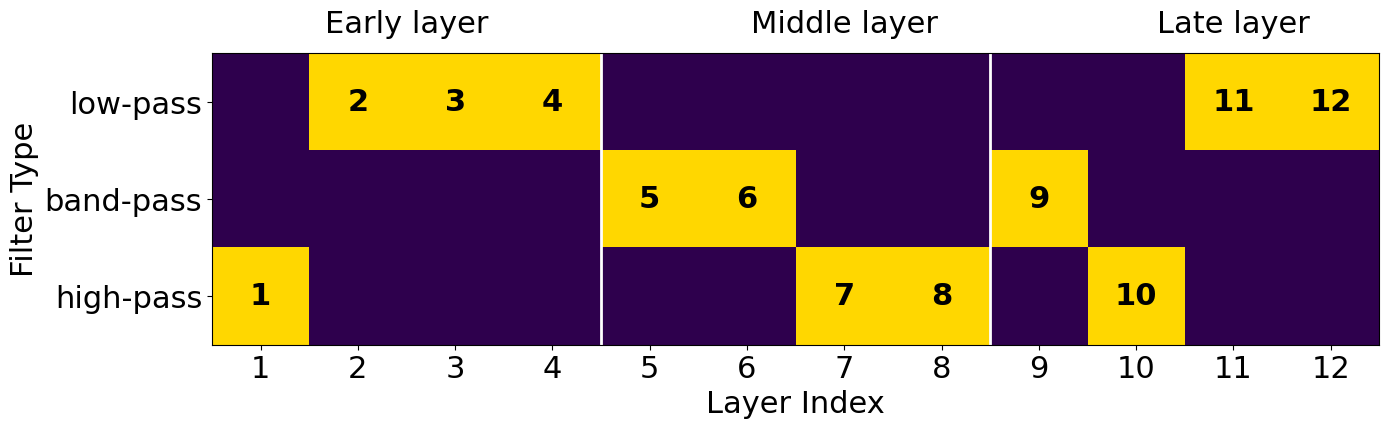

In [72]:
# Plot
forward_matrix,backward_matrix = generate_layer_wise_classification_metrix(forward_codessm_metrics_with_region,backward_codessm_metrics_with_region)
fig_f, ax_f = layer_wise_classification_plot(forward_matrix,"CodeSSM", "Forward")
fig_b, ax_b = layer_wise_classification_plot(backward_matrix,"CodeSSM","Backward")


## codessm_sqa layer-wise classification graph

In [109]:
forward_codessm_sqa_metrics_with_region = classify_all_kernels(forward_codessm_sqa_metrics.copy())

In [110]:
backward_codessm_sqa_metrics_with_region = classify_all_kernels(backward_codessm_sqa_metrics.copy())

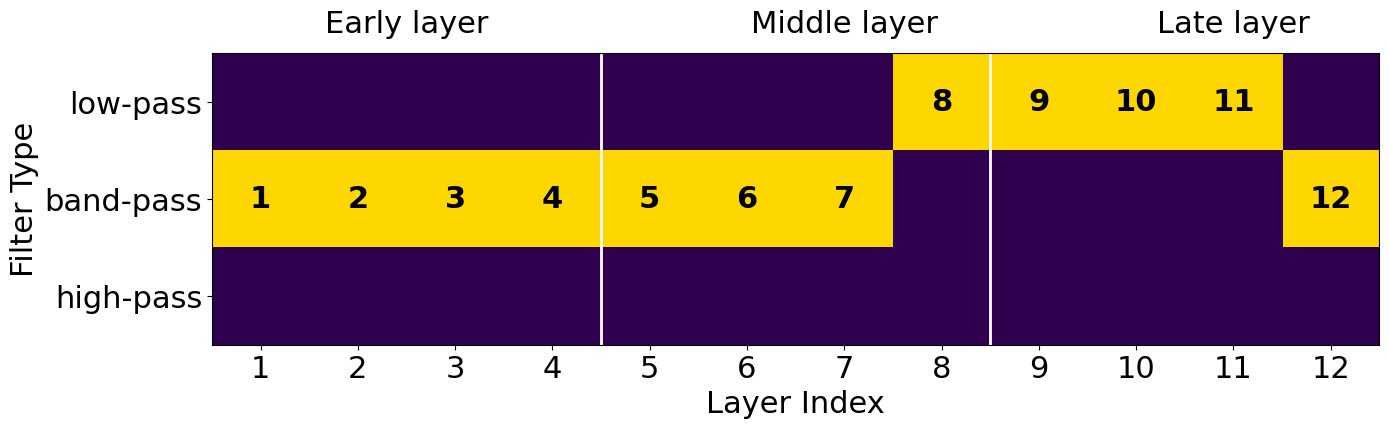

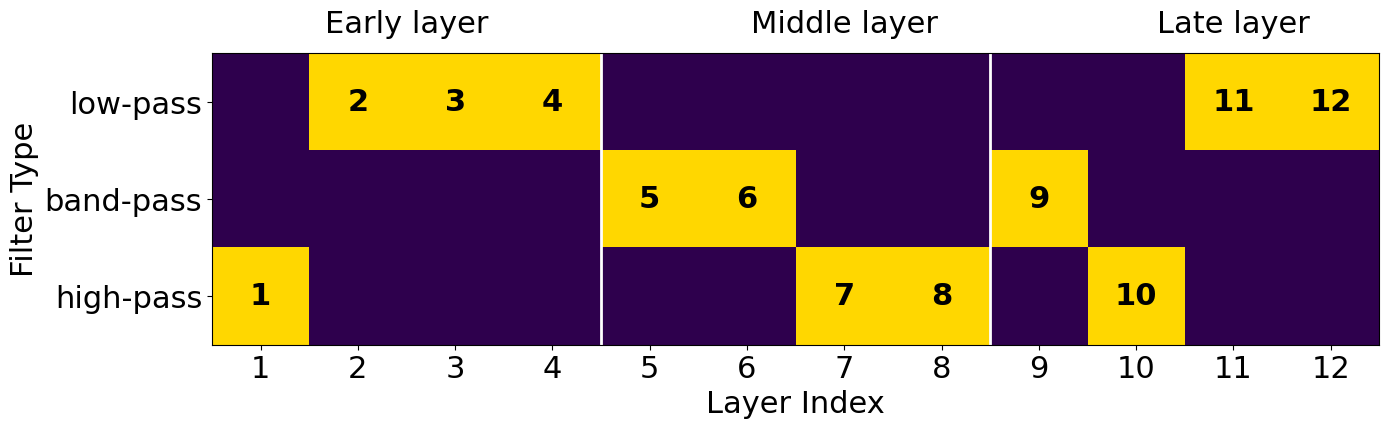

In [113]:
# Plot
forward_sqa_matrix,backward_sqa_matrix = generate_layer_wise_classification_metrix(forward_codessm_sqa_metrics_with_region ,backward_codessm_sqa_metrics_with_region)
fig_f, ax_f = layer_wise_classification_plot(forward_sqa_matrix,"codessm_sqa", "Forward")
fig_b, ax_b = layer_wise_classification_plot(backward_sqa_matrix,"codessm_sqa","Backward")


## codessm_typeinf layer-wise classification graph

In [114]:
forward_codessm_typeinf_metrics_with_region = classify_all_kernels(forward_codessm_typeinf_metrics.copy())

In [115]:
backward_codessm_typeinf_metrics_with_region = classify_all_kernels(backward_codessm_typeinf_metrics.copy())

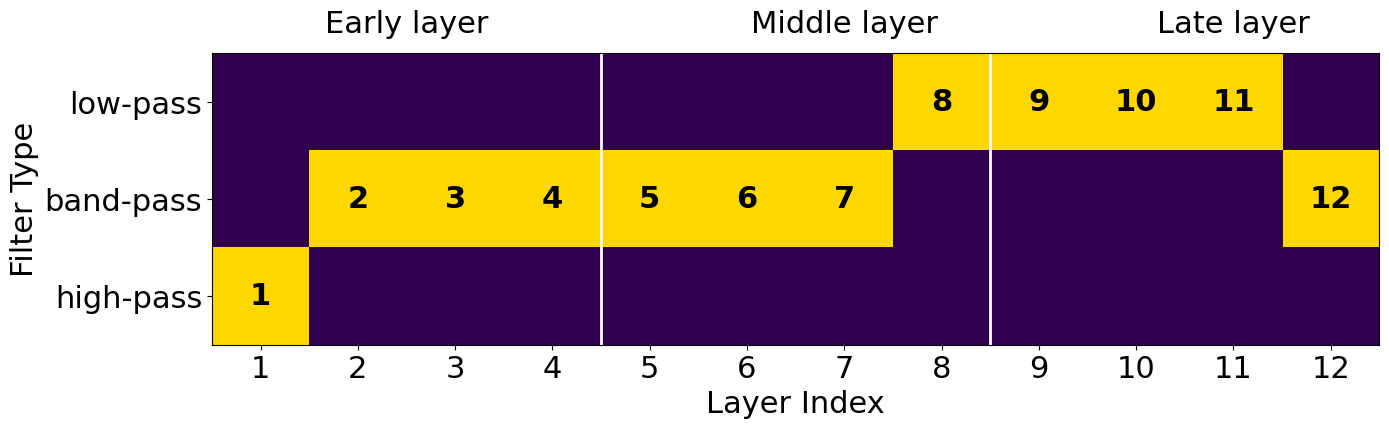

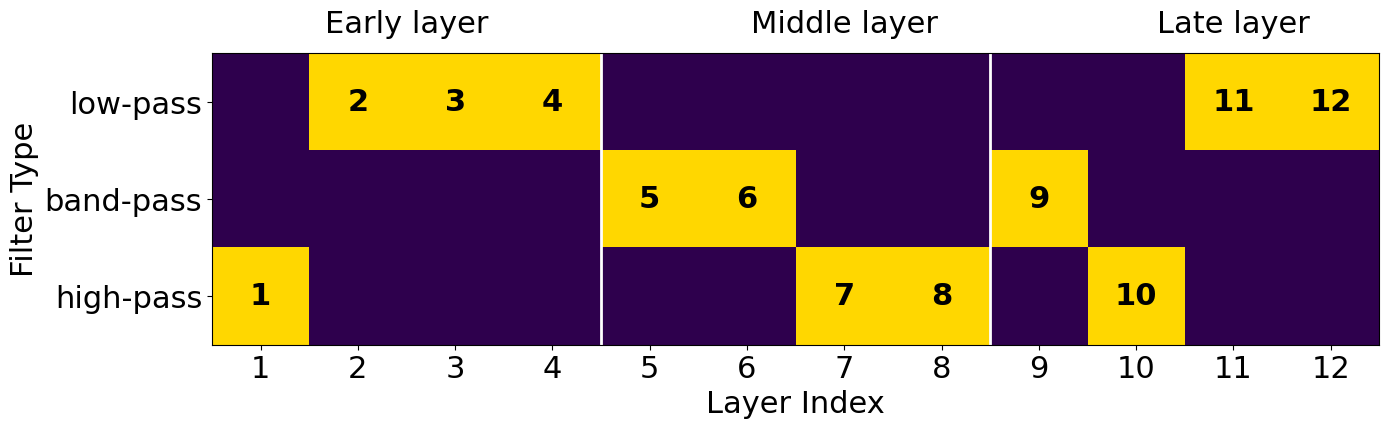

In [116]:
# Plot
forward_typeinf_matrix,backward_typeinf_matrix = generate_layer_wise_classification_metrix(forward_codessm_typeinf_metrics_with_region ,backward_codessm_typeinf_metrics_with_region)
fig_f, ax_f = layer_wise_classification_plot(forward_typeinf_matrix,"codessm_typeinf", "Forward")
fig_b, ax_b = layer_wise_classification_plot(backward_typeinf_matrix,"codessm_typeinf","Backward")

# comparison between spectral centroid of codessm_hf and codessm


In [ ]:
hfconv_metrics = pd.read_csv('./hfconv_metrics.csv')
forward_hfconv_metrics = hfconv_metrics.iloc[::2]
print(forward_hfconv_metrics )

     model  layer direction  dominant_frequency  dominant_magnitude  spectral_centroid  low_freq_energy  high_freq_energy  low_to_high_frequency_ratio     log10
0   hfconv      1   forward            0.000000            0.694261           0.229551       108.159866        136.733048                     0.791029 -0.101807
2   hfconv      2   forward            0.013916            0.330564           0.231212        43.964606         57.724987                     0.761622 -0.118261
4   hfconv      3   forward            0.004883            1.160320           0.204480       340.502715        174.939692                     1.946401  0.289232
6   hfconv      4   forward            0.000000           15.562557           0.233372      2709.707896       1363.543730                     1.987254  0.298253
8   hfconv      5   forward            0.023682            0.535897           0.211226        83.666201         56.021823                     1.493457  0.174193
10  hfconv      6   forward       

In [ ]:
backward_hfconv_metrics = hfconv_metrics.iloc[1::2]
print(backward_hfconv_metrics )

     model  layer direction  dominant_frequency  dominant_magnitude  spectral_centroid  low_freq_energy  high_freq_energy  low_to_high_frequency_ratio     log10
1   hfconv      1  backward            0.024902            2.401621           0.160571       902.394132        263.257338                     3.427802  0.535016
3   hfconv      2  backward            0.000000            3.596159           0.181544       262.864877         25.504736                    10.306513  1.013112
5   hfconv      3  backward            0.147705           13.719318           0.219044       862.562101        214.724741                     4.017060  0.603908
7   hfconv      4  backward            0.008789            2.144797           0.255000       148.780238        344.638576                     0.431699 -0.364819
9   hfconv      5  backward            0.000000            8.485688           0.183973       706.963977         96.309107                     7.340572  0.865730
11  hfconv      6  backward       

In [ ]:
def plot_spectral_centroid(metrics_codessm,metrics_hf,direction):
      os.makedirs("./plots/comparison_of_spectral_centroid", exist_ok=True)
      # Create the plot
      plt.figure(figsize=(10, 6))

      # Plot both sets using their index
      plt.plot(metrics_hf['layer'], metrics_hf['spectral_centroid'], marker='s', label='codessm_hf', linewidth=1,linestyle='dotted',color='green')
      texts = []
      for x, y in zip(metrics_hf['layer'], metrics_hf['spectral_centroid']):
          text = plt.annotate(f"{y:.2f}", xy=(x, y), fontsize=15)
          texts.append(text)
      adjust_text(texts,
                  arrowprops=dict(arrowstyle="-", color='k', lw=0.5))


      plt.plot(metrics_codessm['layer'], metrics_codessm['spectral_centroid'], marker='o', label='codessm', linewidth=1,linestyle='dotted',color='red')
      texts = []
      for x, y in zip(metrics_codessm['layer'], metrics_codessm['spectral_centroid']):
          text = plt.annotate(f"{y:.2f}", xy=(x, y), fontsize=14)
          texts.append(text)
      adjust_text(texts,
                  arrowprops=dict(arrowstyle="-", color='k', lw=0.5))


      plt.grid(True, alpha=0.3)
      plt.xlabel('layer',fontsize=12)
      plt.ylabel('spectral_centroid',fontsize=12)


      #plt.title('Comparison of spectral_centroid')
      plt.xticks(range(1,13))
      plt.legend(fontsize=20)
      plt.savefig(f'./plots/comparison_of_spectral_centroid/{direction}_comparison_spectral_centroid_codessm_hf_and_codessm_annotation.pdf', dpi=300)
      plt.show()

In [ ]:
def plot_spectral_centroid(metrics_codessm,metrics_hf,direction):
      os.makedirs("./plots/comparison_of_spectral_centroid", exist_ok=True)
      # Create the plot
      plt.figure(figsize=(10, 6))

      # Plot both sets using their index
      plt.plot(metrics_hf['layer'], metrics_hf['spectral_centroid'], marker='s', label='codessm_hf', linewidth=1,linestyle='dotted',color='green')
      plt.plot(metrics_codessm['layer'], metrics_codessm['spectral_centroid'], marker='o', label='codessm', linewidth=1,linestyle='dotted',color='red')
      plt.grid(True, alpha=0.3)
      plt.xlabel('layer',fontsize=12)
      plt.ylabel('spectral_centroid',fontsize=12)


      #plt.title('Comparison of spectral_centroid')
      plt.xticks(range(1,13))
      plt.legend(fontsize=20)
      plt.savefig(f'./plots/comparison_of_spectral_centroid/{direction}_comparison_spectral_centroid_codessm_hf_and_codessm.pdf', dpi=300)
      plt.show()

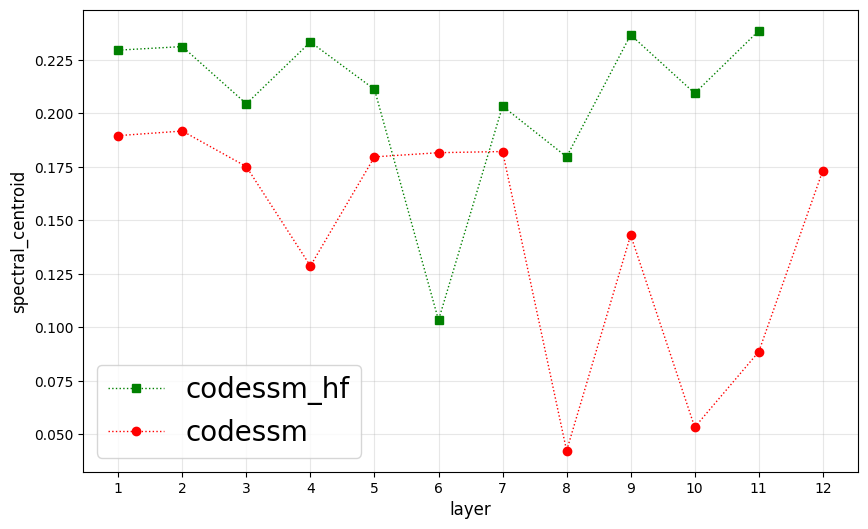

In [ ]:
direction="forward"
plot_spectral_centroid(forward_codessm_metrics,forward_hfconv_metrics,direction)

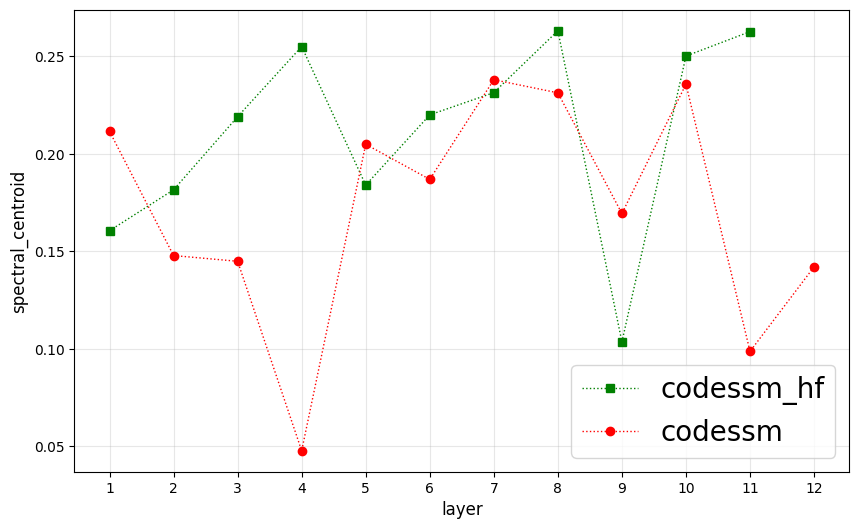

In [ ]:
direction="backward"
plot_spectral_centroid(backward_codessm_metrics,backward_hfconv_metrics,direction)